## < Problem 1 >
![Problem 1](https://github.com/seoupark1/Stochastic-Control/blob/main/assets/images/kalman_filter/extended_kalman_filter/ekf_01.png?raw=true)

In [1]:
# Unpack the Data

import pickle
import urllib.request
import numpy as np
import matplotlib.pyplot as plt

url = ('https://raw.githubusercontent.com/seoupark1/Stochastic-Control/main/studies/kalman_filter/data.pickle')

with urllib.request.urlopen(url) as f:
    data = pickle.load(f)

t = data['t']  # timestamps [s]

x_init  = data['x_init'] # initial x position [m]
y_init  = data['y_init'] # initial y position [m]
th_init = data['th_init'] # initial theta position [rad]

# input signal
v  = data['v']  # translational velocity input [m/s]
om = data['om']  # rotational velocity input [rad/s]

# bearing and range measurements, LIDAR constants
b = data['b']  # bearing to each landmarks center in the frame attached to the laser [rad]
r = data['r']  # range measurements [m]
l = data['l']  # x,y positions of landmarks [m]
d = data['d']  # distance between robot center and laser rangefinder [m]

## < Problem 2 >
![Problem 2](https://github.com/seoupark1/Stochastic-Control/blob/main/assets/images/kalman_filter/extended_kalman_filter/ekf_02.png?raw=true)

In [2]:
# Initializing Parameters

v_var = 0.01  # translation velocity variance
om_var = 0.01  # rotational velocity variance
r_var = 0.1  # range measurements variance
b_var = 0.1  # bearing measurement variance

Q_km = np.diag([v_var, om_var]) # input noise covariance
cov_y = np.diag([r_var, b_var])  # measurement noise covariance

x_est = np.zeros([len(v), 3])  # estimated states, x, y, and theta
P_est = np.zeros([len(v), 3, 3])  # state covariance matrices

x_est[0] = np.array([x_init, y_init, th_init]) # initial state
P_est[0] = np.diag([1, 1, 0.1]) # initial state covariance

In [3]:
# Wraps angle to (-pi,pi] range
def wraptopi(x):
    if x > np.pi:
        x = x - (np.floor(x / (2 * np.pi)) + 1) * 2 * np.pi
    elif x < -np.pi:
        x = x + (np.floor(x / (-2 * np.pi)) + 1) * 2 * np.pi
    return x

## < Problem 3 >
![Problem 3](https://github.com/seoupark1/Stochastic-Control/blob/main/assets/images/kalman_filter/extended_kalman_filter/ekf_03.png?raw=true)


In [4]:
def measurement_update(lk, rk, bk, P_check, x_check):

    # 1. Compute measurement Jacobian
    xl, yl = float(lk[0]), float(lk[1])
    xk, yk, thk = float(x_check[0]), float(x_check[1]), float(x_check[2])
    d_val = float(d)

    dx = xl - xk - d_val*np.cos(thk)
    dy = yl - yk - d_val*np.sin(thk)
    q = dx**2 + dy**2
    dr = np.sqrt(dx**2 + dy**2)

    drdxk = - dx / dr
    drdyk = - dy / dr
    drdthk = (dx * d_val * np.sin(thk) - dy * d_val * np.cos(thk)) / dr
    dphidxk = dy / q
    dphidyk = - dx / q
    dphidthk = - (dx * d_val * np.cos(thk) + dy * d_val * np.sin(thk)) / q - 1

    Hk = np.array([[drdxk, drdyk, drdthk],
                  [dphidxk, dphidyk, dphidthk]])
    Mk = np.eye(2)

    # 2. Compute Kalman Gain
    Kk = P_check @ Hk.T @ np.linalg.inv(Hk @ P_check @ Hk.T + Mk @ cov_y @ Mk.T)

    # 3. Correct predicted state (remember to wrap the angles to [-pi,pi])
    y = np.array([rk, bk])
    y_check = np.array([dr, wraptopi(np.arctan2(dy, dx) - thk)])
    innovation = y - y_check
    innovation[1] = wraptopi(innovation[1])

    x_check = x_check + Kk @ (innovation)
    x_check[2] = wraptopi(x_check[2])

    # 4. Correct covariance
    P_check = (np.eye(3) - Kk@Hk) @ P_check

    return x_check, P_check

## < Problem 4 >
![Problem 4](https://github.com/seoupark1/Stochastic-Control/blob/main/assets/images/kalman_filter/extended_kalman_filter/ekf_04.png?raw=true)


In [5]:
#### 5. Main Filter Loop #######################################################################
for k in range(1, len(t)):  # start at 1 because we've set the initial prediciton

    delta_t = t[k] - t[k - 1]  # time step (difference between timestamps)

    # 1. Update state with odometry readings (remember to wrap the angles to [-pi,pi]
    x_check = x_est[k-1, :] + delta_t * np.array([v[k-1]*np.cos(x_est[k-1, 2]), v[k-1]*np.sin(x_est[k-1, 2]), wraptopi(om[k-1])])
    x_check[2] = wraptopi(x_check[2])

    # 2. Motion model jacobian with respect to last state
    F_km = np.eye(3) + delta_t * np.array([[0, 0, -v[k-1]*np.sin(x_est[k-1, 2])],
                                          [0, 0, v[k-1]*np.cos(x_est[k-1, 2])],
                                          [0, 0, 0]])

    # 3. Motion model jacobian with respect to noise
    L_km = delta_t * np.array([[np.cos(x_est[k-1, 2]), 0],
                              [np.sin(x_est[k-1, 2]), 0],
                              [0, 1]])

    # 4. Propagate uncertainty
    P_check = F_km @ P_est[k-1] @ F_km.T + L_km @ Q_km @ L_km.T

    # 5. Update state estimate using available landmark measurements
    for i in range(len(r[k])):
        x_check, P_check = measurement_update(l[i], r[k, i], b[k, i], P_check, x_check)

    # Set final state predictions for timestep
    x_est[k, 0] = x_check[0]
    x_est[k, 1] = x_check[1]
    x_est[k, 2] = x_check[2]
    P_est[k, :, :] = P_check

/tmp/ipykernel_31479/1230096451.py:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  d_val = float(d)


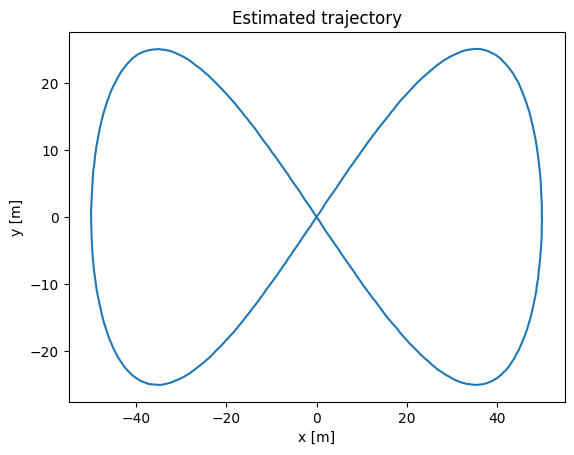

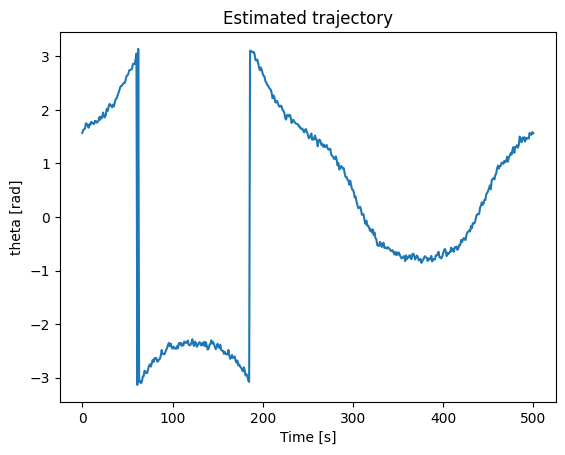

In [6]:
e_fig = plt.figure()
ax = e_fig.add_subplot(111)
ax.plot(x_est[:, 0], x_est[:, 1])
ax.set_xlabel('x [m]')
ax.set_ylabel('y [m]')
ax.set_title('Estimated trajectory')
plt.show()

e_fig = plt.figure()
ax = e_fig.add_subplot(111)
ax.plot(t[:], x_est[:, 2])
ax.set_xlabel('Time [s]')
ax.set_ylabel('theta [rad]')
ax.set_title('Estimated trajectory')
plt.show()